In [216]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("ames_housing.csv")

#Splicing the variables into numerical and categorical and ordinal for each section of data
ames = df.copy()

#Location and Land Varaibles
location_land_categorical = ["MS_Zoning", "Neighborhood", "Lot_Config"]
location_land_numerical = ["Lot_Area", "Lot_Frontage"]
location_land_ordinal = ["Lot_Shape", "Land_Contour", "Land_Slope"]

maps_location_land = {
    "Lot_Shape": {"IR3": 1, "IR2": 2, "IR1": 3,"Reg": 4},
    "Land_Contour": {"Lvl": 3, "HLS": 2, "Bnk": 2, "Low": 1},
    "Land_Slope": {"Sev": 0, "Mod": 1, "Gtl": 2}
}

for col, mapping in maps_location_land.items():
    ames[col] = ames[col].map(mapping)

#Filling in relavant missing values. A property must have a Lot frontage so we fill the few missing vals with the median
ames["Lot_Frontage"] = df["Lot_Frontage"].fillna(df["Lot_Frontage"].median())

#Aggregating all the location_land vars
location_land_all = location_land_categorical + location_land_numerical + location_land_ordinal

#Building Type and Age
building_type_numerical = ["Year_Built", "Year_Remod_Add"]
building_type_categorical = ["Bldg_Type", "House_Style", "MS_SubClass"]

building_type_total = building_type_numerical + building_type_categorical

#Quality and Condition
quality_and_condition_numerical = ["Overall_Qual", "Overall_Cond"]
quality_and_condition_ordinals =  ["Exter_Qual", "Exter_Cond", "Kitchen_Qual", "Heating_QC"]
quality_map = {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}

for col in quality_and_condition_ordinals:
    ames[col] = ames[col].map(quality_map)

quality_and_condition_total = quality_and_condition_numerical + quality_and_condition_ordinals


#Size and Rooms
size_and_rooms_numeric = ["Gr_Liv_Area", "X1st_Flr_SF", "X2nd_Flr_SF", "Total_Bsmt_SF", "Full_Bath", "Half_Bath", "Bedroom_AbvGr", "Kitchen_AbvGr", "TotRms_AbvGrd"]
ames["Total_Bsmt_SF"] = ames["Total_Bsmt_SF"].fillna(0)

size_and_rooms_total = size_and_rooms_numeric

#Basement and Garage
basement_garage_numerical = ["Garage_Cars", "Garage_Area"]
basement_garage_categorical = ["Garage_Type"]
basement_garage_ordinal = ["Bsmt_Qual", "Bsmt_Cond", "Bsmt_Exposure", "BsmtFin_Type_1", "Garage_Finish"]

#We fill the numerical null values with 0 and the categorical and ordinal with 0 assuming that null values correspond to the lack of a basement
ames["Garage_Cars"] = ames["Garage_Cars"].fillna(0)
ames["Garage_Area"] = ames["Garage_Area"].fillna(0)
ames["Garage_Type"] = ames["Garage_Type"].fillna("No_Garage")

for col in basement_garage_ordinal:
    ames[col] = ames[col].fillna("None")

basement_garage_maps = {
    "Bsmt_Qual": {"None": 0, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "Bsmt_Cond": {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "Bsmt_Exposure": {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4},
    "BsmtFin_Type_1": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "Garage_Finish": {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3}
}

for col, mapping in basement_garage_maps.items():
    ames[col] = ames[col].map(mapping)

basement_garage_total = basement_garage_numerical + basement_garage_categorical + basement_garage_ordinal

#Sale Variables
sale_variables_numeric = ["Yr_Sold"]
sale_cyclical = ["Mo_Sold"]
sale_categorical = ["Sale_Type", "Sale_Condition"]

sale_total = sale_variables_numeric + sale_cyclical + sale_categorical

ames["Mo_Sold"] = np.sin(2 * np.pi * ames["Mo_Sold"] / 12)

#Aggregting all categorical variables
categorical_vars = sale_categorical + basement_garage_categorical + building_type_categorical + location_land_categorical 
numerical_vars = sale_variables_numeric + basement_garage_numerical + building_type_numerical + location_land_numerical + quality_and_condition_numerical + size_and_rooms_numeric
ordinal_vars = basement_garage_ordinal + location_land_ordinal+ quality_and_condition_ordinals

total_columns = categorical_vars + numerical_vars + ordinal_vars

ames = ames[total_columns]


In [217]:
ames_encoded = pd.get_dummies(
    ames,
    columns=categorical_vars,
    drop_first=True
)

In [223]:
ames_encoded

,Yr_Sold,Garage_Cars,Garage_Area,Year_Built,Year_Remod_Add,Lot_Area,Lot_Frontage,Overall_Qual,Overall_Cond,Gr_Liv_Area,...,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Lot_Config_CulDSac,Lot_Config_FR2,Lot_Config_FR3,Lot_Config_Inside
0,2010,2.0,528.0,1960,1960,31770,141.0,6,5,1656,...,False,False,False,False,False,False,False,False,False,False
1,2010,1.0,730.0,1961,1961,11622,80.0,5,6,896,...,False,False,False,False,False,False,False,False,False,True
2,2010,1.0,312.0,1958,1958,14267,81.0,6,6,1329,...,False,False,False,False,False,False,False,False,False,False
3,2010,2.0,522.0,1968,1968,11160,93.0,7,5,2110,...,False,False,False,False,False,False,False,False,False,False
4,2010,2.0,482.0,1997,1998,13830,74.0,5,5,1629,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2006,2.0,588.0,1984,1984,7937,37.0,6,6,1003,...,False,False,False,False,False,False,True,False,False,False
2926,2006,2.0,484.0,1983,1983,8885,68.0,5,5,902,...,False,False,False,False,False,False,False,False,False,True
2927,2006,0.0,0.0,1992,1992,10441,62.0,5,5,970,...,False,False,False,False,False,False,False,False,False,True
2928,2006,2.0,418.0,1974,1975,10010,77.0,5,5,1389,...,False,False,False,False,False,False,False,False,False,True


In [218]:
df["Alley"].value_counts()

Alley
Grvl    120
Pave     78
Name: count, dtype: int64

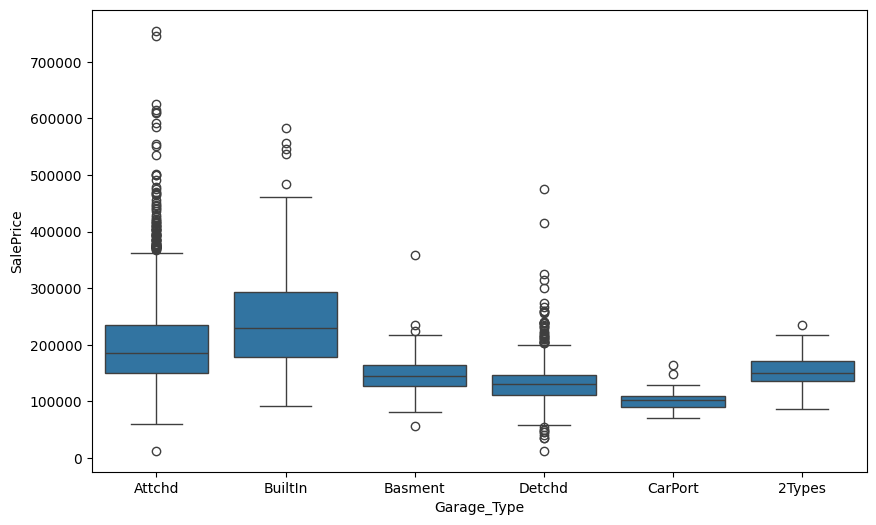

In [219]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Garage_Type", y="SalePrice")
plt.show()

In [220]:

target = "SalePrice"
categorical_target = "HighSalePrice"
disguised_numerical_vars = ["MS_SubClass", "Mo_Sold"]

X = df.drop(columns=["SalePrice", "HighSalePrice"])
y = df[target]

numeric_cols = X.select_dtypes(include=["int64", "float64"]).drop(columns=disguised_numerical_vars)
categorical_cols = X.select_dtypes(include=["object"]).columns

In [221]:
numeric_cols

,Lot_Frontage,Lot_Area,Overall_Qual,Overall_Cond,Year_Built,Year_Remod_Add,Mas_Vnr_Area,BsmtFin_SF_1,BsmtFin_SF_2,Bsmt_Unf_SF,...,Garage_Cars,Garage_Area,Wood_Deck_SF,Open_Porch_SF,Enclosed_Porch,X3Ssn_Porch,Screen_Porch,Pool_Area,Misc_Val,Yr_Sold
0,141.0,31770,6,5,1960,1960,112.0,639.0,0.0,441.0,...,2.0,528.0,210,62,0,0,0,0,0,2010
1,80.0,11622,5,6,1961,1961,0.0,468.0,144.0,270.0,...,1.0,730.0,140,0,0,0,120,0,0,2010
2,81.0,14267,6,6,1958,1958,108.0,923.0,0.0,406.0,...,1.0,312.0,393,36,0,0,0,0,12500,2010
3,93.0,11160,7,5,1968,1968,0.0,1065.0,0.0,1045.0,...,2.0,522.0,0,0,0,0,0,0,0,2010
4,74.0,13830,5,5,1997,1998,0.0,791.0,0.0,137.0,...,2.0,482.0,212,34,0,0,0,0,0,2010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,37.0,7937,6,6,1984,1984,0.0,819.0,0.0,184.0,...,2.0,588.0,120,0,0,0,0,0,0,2006
2926,NaN,8885,5,5,1983,1983,0.0,301.0,324.0,239.0,...,2.0,484.0,164,0,0,0,0,0,0,2006
2927,62.0,10441,5,5,1992,1992,0.0,337.0,0.0,575.0,...,0.0,0.0,80,32,0,0,0,0,700,2006
2928,77.0,10010,5,5,1974,1975,0.0,1071.0,123.0,195.0,...,2.0,418.0,240,38,0,0,0,0,0,2006


Splitting these into values categorical and numerical variables & cleaning the data

In [222]:
numerical_predictors = X[numeric_cols]
categorical_predictors = X[categorical_cols]

ValueError: Boolean array expected for the condition, not object

In [ ]:
missing_numerical = numerical_predictors.isnull().mean()
missing_numerical[missing_numerical > 0]

Lot_Frontage      0.167235
Mas_Vnr_Area      0.007850
BsmtFin_SF_1      0.000341
BsmtFin_SF_2      0.000341
Bsmt_Unf_SF       0.000341
Total_Bsmt_SF     0.000341
Bsmt_Full_Bath    0.000683
Bsmt_Half_Bath    0.000683
Garage_Yr_Blt     0.054266
Garage_Cars       0.000341
Garage_Area       0.000341
dtype: float64

In [ ]:
df.loc[df["Lot_Frontage"].isna(), :]

,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,...,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Yr_Sold,Sale_Type,Sale_Condition,SalePrice,HighSalePrice
11,20,RL,NaN,7980,Pave,NaN,IR1,Lvl,AllPub,Inside,...,NaN,GdPrv,Shed,500,3,2010,WD,Normal,185000,High
14,120,RL,NaN,6820,Pave,NaN,IR1,Lvl,AllPub,Corner,...,NaN,NaN,NaN,0,6,2010,WD,Normal,212000,High
22,60,FV,NaN,7500,Pave,NaN,Reg,Lvl,AllPub,Inside,...,NaN,NaN,NaN,0,1,2010,WD,Normal,216000,High
23,20,RL,NaN,11241,Pave,NaN,IR1,Lvl,AllPub,CulDSac,...,NaN,NaN,Shed,700,3,2010,WD,Normal,149000,Low
24,20,RL,NaN,12537,Pave,NaN,IR1,Lvl,AllPub,CulDSac,...,NaN,NaN,NaN,0,4,2010,WD,Normal,149900,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2894,20,RL,NaN,16669,Pave,NaN,IR1,Lvl,AllPub,Corner,...,NaN,NaN,NaN,0,1,2006,WD,Normal,228000,High
2897,60,RL,NaN,11170,Pave,NaN,IR2,Lvl,AllPub,Corner,...,NaN,GdPrv,NaN,0,4,2006,WD,Normal,250000,High
2898,20,RL,NaN,8098,Pave,NaN,IR1,Lvl,AllPub,Inside,...,NaN,NaN,NaN,0,10,2006,WD,Normal,202000,High
2912,90,RL,NaN,11836,Pave,NaN,IR1,Lvl,AllPub,Corner,...,NaN,NaN,NaN,0,3,2006,WD,Normal,146500,Low


In [ ]:
missing_categorical = categorical_predictors.isnull().mean()
missing_categorical[missing_categorical > 0]

Alley             0.932423
Mas_Vnr_Type      0.605802
Bsmt_Qual         0.027304
Bsmt_Cond         0.027304
Bsmt_Exposure     0.028328
BsmtFin_Type_1    0.027304
BsmtFin_Type_2    0.027645
Electrical        0.000341
Fireplace_Qu      0.485324
Garage_Type       0.053584
Garage_Finish     0.054266
Garage_Qual       0.054266
Garage_Cond       0.054266
Pool_QC           0.995563
Fence             0.804778
Misc_Feature      0.963823
dtype: float64

In [ ]:
from sklearn.preprocessing import PCA, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

scaler = StandardScaler()



ImportError: cannot import name 'PCA' from 'sklearn.preprocessing' (/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/preprocessing/__init__.py)

In [ ]:
X.dtypes.value_counts()

object     43
int64      25
float64    11
Name: count, dtype: int64

Null Value processing

In [ ]:
missing = X[categorical_cols].isnull().mean().sort_values(ascending=False)
print(missing[missing > 0])

Pool_QC           0.995563
Misc_Feature      0.963823
Alley             0.932423
Fence             0.804778
Mas_Vnr_Type      0.605802
Fireplace_Qu      0.485324
Garage_Cond       0.054266
Garage_Qual       0.054266
Garage_Finish     0.054266
Garage_Type       0.053584
Bsmt_Exposure     0.028328
BsmtFin_Type_2    0.027645
BsmtFin_Type_1    0.027304
Bsmt_Qual         0.027304
Bsmt_Cond         0.027304
Electrical        0.000341
dtype: float64


In [ ]:
df["Alley"].value_counts()

Alley
Grvl    120
Pave     78
Name: count, dtype: int64

In [ ]:
df["Bsmt_Unf_SF"].value_counts()

Bsmt_Unf_SF
0.0       244
384.0      19
728.0      14
672.0      13
600.0      12
         ... 
1442.0      1
1099.0      1
804.0       1
154.0       1
239.0       1
Name: count, Length: 1137, dtype: int64